In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

# SHEET 1: STOCK PRICES - INNOVATETECH (750 trading days)

dates = pd.bdate_range(start='2023-01-02', periods=750)

prices = [150.0]
for i in range(1, len(dates)):
    # Daily return with slight upward drift
    daily_return = np.random.normal(0.0005, 0.017)
    new_price = prices[-1] * (1 + daily_return)
    prices.append(max(new_price, 20))

prices = np.array(prices)

stock_df = pd.DataFrame({
    'date': dates,
    'ticker': 'INNOVATETECH',
    'open': (prices * (1 + np.random.uniform(-0.005, 0.005, len(dates)))).round(2),
    'high': (prices * (1 + np.random.uniform(0.003, 0.015, len(dates)))).round(2),
    'low':  (prices * (1 - np.random.uniform(0.003, 0.015, len(dates)))).round(2),
    'close': prices.round(2),
    'volume': np.random.randint(500000, 1500000, len(dates))
})

# SHEET 2: SALES DATA - BazaarMart (4 stores, 730 days)

sales_dates = pd.date_range(start='2023-01-01', periods=730, freq='D')
stores = ['Downtown', 'Uptown', 'Suburb', 'Mall']
base_sales = {'Downtown': 500, 'Uptown': 620, 'Suburb': 400, 'Mall': 750}
growth_rates = {'Downtown': 0.30, 'Uptown': 0.50, 'Suburb': 0.20, 'Mall': 0.45}

sales_records = []
for store in stores:
    for i, d in enumerate(sales_dates):
        trend = base_sales[store] * (1 + growth_rates[store] * i / 730)
        # Weekly seasonality: weekends higher
        weekday_factor = 1.25 if d.weekday() >= 5 else 0.95
        # Yearly seasonality: Nov-Dec higher
        month_factor = 1.20 if d.month in [11, 12] else 1.0
        noise = np.random.normal(0, 35)
        value = trend * weekday_factor * month_factor + noise
        sales_records.append({
            'date': d, 'store': store,
            'sales': round(max(value, 50), 1)
        })

sales_df = pd.DataFrame(sales_records)


# SHEET 3: WAITER TIPS - SpiceGarden (300 bills)

total_bills = np.random.uniform(10, 60, 300).round(2)
tips = (total_bills * 0.17 + np.random.normal(0, 1.0, 300)).round(2)
tips = np.clip(tips, 0.5, 15.0)

tips_df = pd.DataFrame({
    'total_bill': total_bills,
    'tip': tips,
    'sex': np.random.choice(['Male', 'Female'], 300),
    'smoker': np.random.choice(['Yes', 'No'], 300, p=[0.35, 0.65]),
    'day': np.random.choice(['Thur', 'Fri', 'Sat', 'Sun'], 300,
                             p=[0.2, 0.15, 0.35, 0.3]),
    'time': np.random.choice(['Lunch', 'Dinner'], 300, p=[0.35, 0.65]),
    'size': np.random.choice([1, 2, 3, 4, 5, 6], 300,
                              p=[0.08, 0.5, 0.2, 0.15, 0.05, 0.02])
})


# SAVE AS EXCEL

with pd.ExcelWriter('predictive_analytics_custom.xlsx') as writer:
    stock_df.to_excel(writer, sheet_name='Stock_Prices', index=False)
    sales_df.to_excel(writer, sheet_name='Sales_Data', index=False)
    tips_df.to_excel(writer, sheet_name='Waiter_Tips', index=False)

print("✅ Dataset created: predictive_analytics_custom.xlsx")
print(f"Stock: {stock_df.shape}")
print(f"Sales: {sales_df.shape}")
print(f"Tips:  {tips_df.shape}")

✅ Dataset created: predictive_analytics_custom.xlsx
Stock: (750, 7)
Sales: (2920, 3)
Tips:  (300, 7)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'

xl = pd.ExcelFile('predictive_analytics_custom.xlsx')
print(xl.sheet_names)

['Stock_Prices', 'Sales_Data', 'Waiter_Tips']


## Part 1 — Stock Price Prediction Using an LSTM Neural Network

An LSTM (Long Short-Term Memory) network is well suited to sequences, such as a stock's daily closing price. We will:
1. Take INNOVATETECH's closing prices
2. Scale them to [0, 1]
3. Build sliding windows (past 20 days → next day)
4. Train a small LSTM and evaluate on unseen, later dates

In [4]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.8/351.2 MB 5.8 MB/s eta 0:01:01
   ---------------------------------------- 3.1/351.2 MB 6.7 MB/s eta 0:00:53
    --------------------------------------- 4.7/351.2 MB 6.7 MB/s eta 0:00:52
    --------------------------------------- 6.3/351.2 MB 6.8 MB/s eta 0:00:52
    --------------------------------------- 7.6/351.2 MB 6.9 MB/s eta 0:00:51
   - -------------------------------------- 9.2/351.2 MB 6.9 MB/s eta 0:00:50
   - -------------------------------------- 10.7/351.2 MB 7.0 MB/s eta 0:00:49
   - -------------------------------------- 12.3/351.2 MB 7.1 MB/s eta 0:00:48
   - -------------------------------------- 13.9/351.2 MB 7.2 MB/s eta 0:00:48
   - -------------------------------------- 15.5/351.2 MB 7.2 MB/s eta 0:00

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.


(750, 7)


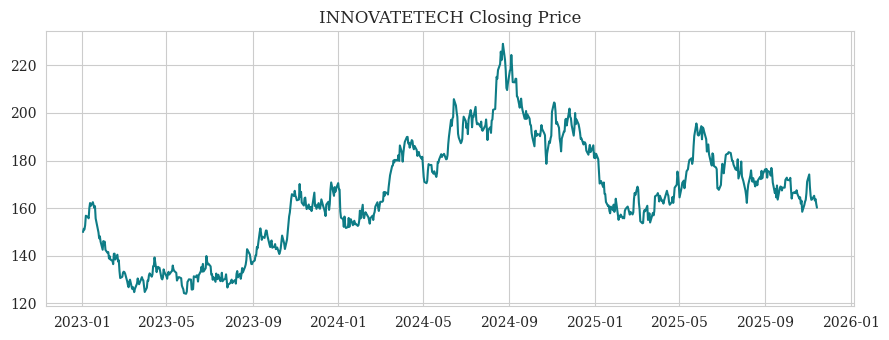

In [5]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

tf.random.set_seed(42)

stock = pd.read_excel('predictive_analytics_custom.xlsx',
                       sheet_name='Stock_Prices', parse_dates=['date'])
innovate = stock[stock['ticker']=='INNOVATETECH'].sort_values('date').reset_index(drop=True)
print(innovate.shape)

plt.figure(figsize=(9,3.5))
plt.plot(innovate['date'], innovate['close'], color='#0E7C86')
plt.title('INNOVATETECH Closing Price')
plt.tight_layout(); plt.show()

In [6]:
prices = innovate['close'].values.reshape(-1,1)

scaler = MinMaxScaler()
scaled = scaler.fit_transform(prices)

WINDOW = 20
X, y = [], []
for i in range(WINDOW, len(scaled)):
    X.append(scaled[i-WINDOW:i, 0])
    y.append(scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Time-based split: train on earlier ~80%, test on later ~20%
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (584, 20, 1)  Test: (146, 20, 1)


In [7]:
model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, 1)),
    keras.layers.LSTM(32, return_sequences=False),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1),
])
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

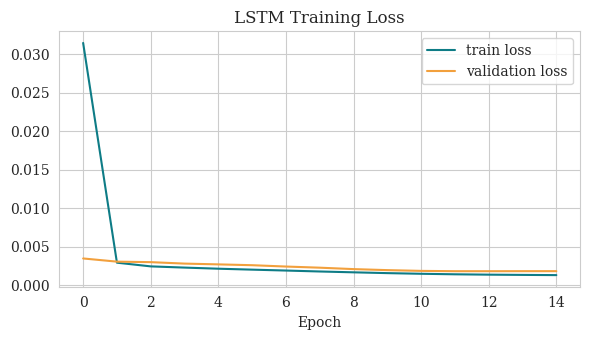

In [8]:
history = model.fit(X_train, y_train, epochs=15, batch_size=16,
                     validation_data=(X_test, y_test), verbose=0)

plt.figure(figsize=(6,3.5))
plt.plot(history.history['loss'], label='train loss', color='#0E7C86')
plt.plot(history.history['val_loss'], label='validation loss', color='#F2A03D')
plt.legend(); plt.title('LSTM Training Loss'); plt.xlabel('Epoch')
plt.tight_layout(); plt.show()

LSTM RMSE on held-out (later) test dates: $4.51


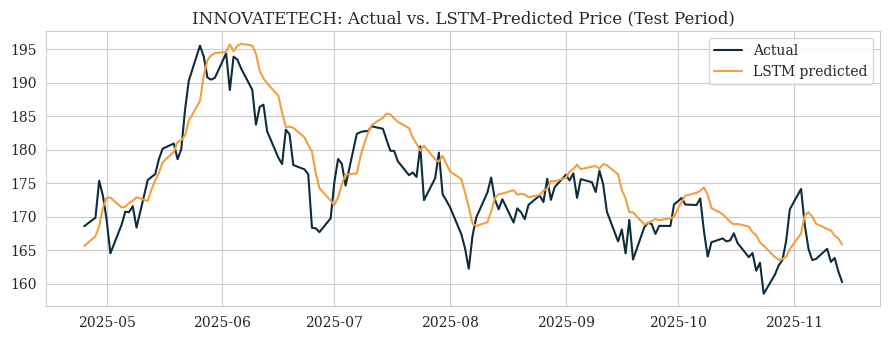

In [9]:
pred_scaled = model.predict(X_test, verbose=0)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y_test.reshape(-1,1))

rmse = mean_squared_error(actual, pred) ** 0.5
print(f"LSTM RMSE on held-out (later) test dates: ${rmse:.2f}")

test_dates = innovate['date'].values[WINDOW+split:]
plt.figure(figsize=(9,3.5))
plt.plot(test_dates, actual, label='Actual', color='#0F2C3D')
plt.plot(test_dates, pred, label='LSTM predicted', color='#F2A03D')
plt.title('INNOVATETECH: Actual vs. LSTM-Predicted Price (Test Period)')
plt.legend(); plt.tight_layout(); plt.show()

**Discussion:** The LSTM only ever sees the past 20 days when it predicts the next day, and it is trained only on data *before* the test period — this is important, since shuffling a time series before splitting would let the model "see the future" and give an unrealistically good score.

## Part 2 — Sales Forecasting and Time-Series Analysis

Next, we forecast daily sales for one store, using classical time-series decomposition and Exponential Smoothing (Holt-Winters), which explicitly models trend and seasonality.

(730,)


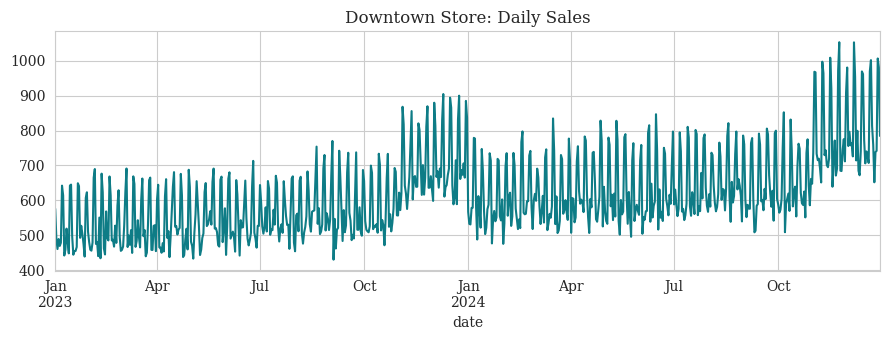

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sales = pd.read_excel('predictive_analytics_custom.xlsx',
                       sheet_name='Sales_Data', parse_dates=['date'])
downtown = sales[sales['store']=='Downtown'].sort_values('date').set_index('date')['sales']
print(downtown.shape)
downtown.plot(figsize=(9,3.5), color='#0E7C86',
              title='Downtown Store: Daily Sales')
plt.tight_layout(); plt.show()

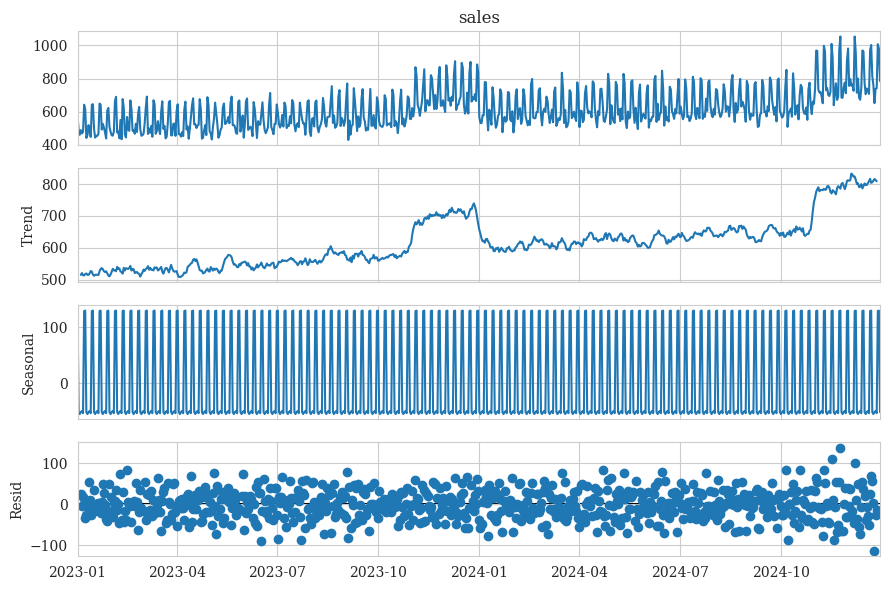

In [11]:
decomp = seasonal_decompose(downtown, model='additive', period=7)
fig = decomp.plot()
fig.set_size_inches(9,6)
plt.tight_layout(); plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Holt-Winters RMSE on held-out 60 days: 137.5 units/day


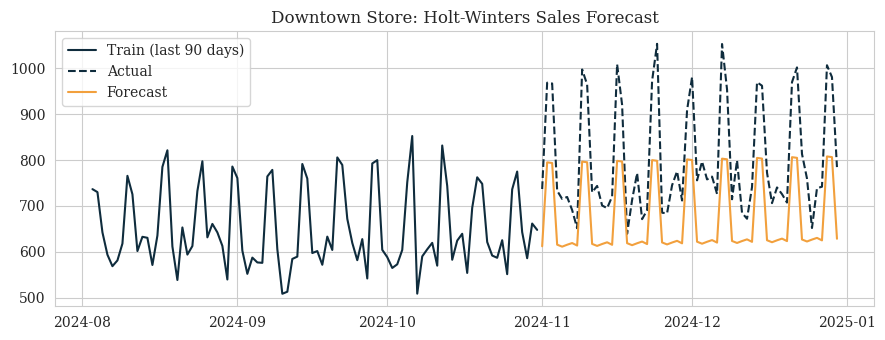

In [12]:
# Time-based split: last 60 days as the test period
train, test = downtown[:-60], downtown[-60:]

hw_model = ExponentialSmoothing(train, trend='add', seasonal='add',
                                 seasonal_periods=7).fit()
forecast = hw_model.forecast(len(test))

rmse_hw = mean_squared_error(test, forecast) ** 0.5
print(f"Holt-Winters RMSE on held-out 60 days: {rmse_hw:.1f} units/day")

plt.figure(figsize=(9,3.5))
plt.plot(train[-90:], label='Train (last 90 days)', color='#0F2C3D')
plt.plot(test, label='Actual', color='#0F2C3D', linestyle='--')
plt.plot(test.index, forecast, label='Forecast', color='#F2A03D')
plt.title('Downtown Store: Holt-Winters Sales Forecast')
plt.legend(); plt.tight_layout(); plt.show()

## Part 3 — Waiter Tips Prediction and Regression Refinement

Now a simpler, tabular regression problem: predict the tip amount from bill size and visit details. We start with a plain baseline model, then refine it and check whether refinement actually helps.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

tips = pd.read_excel('predictive_analytics_custom.xlsx',
                      sheet_name='Waiter_Tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,12.68,4.11,Female,Yes,Fri,Dinner,3
1,17.02,2.99,Male,No,Sat,Dinner,2
2,41.13,5.96,Male,No,Thur,Lunch,4
3,20.39,2.64,Male,No,Sat,Lunch,3
4,35.20,7.75,Male,Yes,Sat,Dinner,2


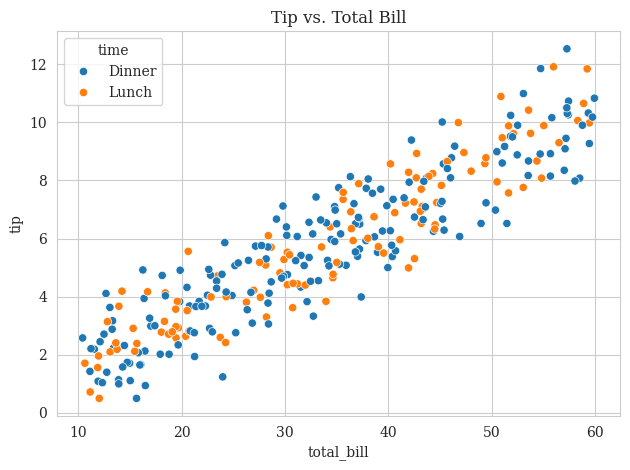

Correlation between total_bill and tip: 0.918


In [14]:
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time')
plt.title('Tip vs. Total Bill')
plt.tight_layout(); plt.show()

print("Correlation between total_bill and tip:",
      round(tips['total_bill'].corr(tips['tip']), 3))

In [15]:
X = tips.drop(columns='tip')
y = tips['tip']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = ['sex','smoker','day','time']
num_cols = ['total_bill','size']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols),
])

# Baseline: total_bill only
baseline = LinearRegression()
baseline.fit(X_train[['total_bill']], y_train)
baseline_pred = baseline.predict(X_test[['total_bill']])
baseline_r2 = r2_score(y_test, baseline_pred)
print(f"Baseline (total_bill only) R²: {baseline_r2:.3f}")

Baseline (total_bill only) R²: 0.826


In [16]:
# Refinement 1: full feature set + linear regression
linreg_pipe = Pipeline([('prep', preprocess), ('model', LinearRegression())])
linreg_pipe.fit(X_train, y_train)
linreg_r2 = r2_score(y_test, linreg_pipe.predict(X_test))
print(f"Refined linear regression (all features) R²: {linreg_r2:.3f}")

# Refinement 2: Ridge regression
ridge_pipe = Pipeline([('prep', preprocess), ('model', Ridge(alpha=1.0))])
ridge_pipe.fit(X_train, y_train)
ridge_r2 = r2_score(y_test, ridge_pipe.predict(X_test))
print(f"Ridge regression (all features) R²: {ridge_r2:.3f}")

# Refinement 3: Random Forest
rf_pipe = Pipeline([('prep', preprocess),
                     ('model', RandomForestRegressor(n_estimators=200, random_state=42))])
rf_pipe.fit(X_train, y_train)
rf_r2 = r2_score(y_test, rf_pipe.predict(X_test))
print(f"Random Forest (all features) R²: {rf_r2:.3f}")

Refined linear regression (all features) R²: 0.821
Ridge regression (all features) R²: 0.821
Random Forest (all features) R²: 0.775


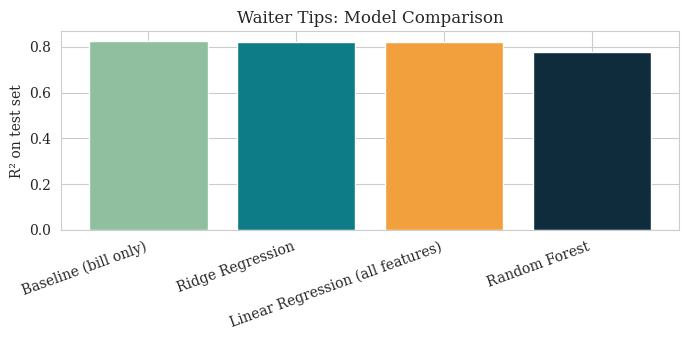

,Model,R2
0,Baseline (bill only),0.826379
1,Ridge Regression,0.820726
2,Linear Regression (all features),0.820690
3,Random Forest,0.775231


In [17]:
comparison = pd.DataFrame({
    "Model": ["Baseline (bill only)", "Linear Regression (all features)",
              "Ridge Regression", "Random Forest"],
    "R2": [baseline_r2, linreg_r2, ridge_r2, rf_r2],
})
comparison = comparison.sort_values("R2", ascending=False).reset_index(drop=True)

plt.figure(figsize=(7,3.5))
plt.bar(comparison['Model'], comparison['R2'],
        color=['#8FBF9F','#0E7C86','#F2A03D','#0F2C3D'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('R² on test set')
plt.title('Waiter Tips: Model Comparison')
plt.tight_layout(); plt.show()
comparison

**Discussion:** Adding day, time, and party size on top of total_bill usually improves R² only modestly, since total_bill alone already captures most of the signal. This is a useful, realistic result: refinement does not always produce a dramatically better model, and knowing *why* is part of the analysis.

## Part 4 — Deploying a Prediction Pipeline

A trained model is only useful if it can be reused without retraining. We save the entire preprocessing + model pipeline as a single file, then show how another program would load it and make predictions on brand-new data.

In [18]:
import joblib

joblib.dump(rf_pipe, 'tips_pipeline.joblib')
print("✅ Pipeline saved to tips_pipeline.joblib")

# Simulate a separate process loading the saved pipeline
loaded_pipe = joblib.load('tips_pipeline.joblib')

new_bills = pd.DataFrame([
    {"total_bill": 45.00, "sex": "Male", "smoker": "No",
     "day": "Sat", "time": "Dinner", "size": 4},
    {"total_bill": 18.50, "sex": "Female", "smoker": "Yes",
     "day": "Thur", "time": "Lunch", "size": 2},
])
predicted_tips = loaded_pipe.predict(new_bills)
new_bills['predicted_tip'] = predicted_tips.round(2)
new_bills

✅ Pipeline saved to tips_pipeline.joblib


,total_bill,sex,smoker,day,time,size,predicted_tip
0,45.0,Male,No,Sat,Dinner,4,7.59
1,18.5,Female,Yes,Thur,Lunch,2,3.24


In a real deployment, this same `joblib.load(...)` → `pipeline.predict(...)` pattern sits behind a web API. A minimal FastAPI example:

```python
from fastapi import FastAPI
import joblib, pandas as pd

app = FastAPI()
pipe = joblib.load("tips_pipeline.joblib")

@app.post("/predict")
def predict(total_bill: float, sex: str, smoker: str, day: str, time: str, size: int):
    row = pd.DataFrame([{
        "total_bill": total_bill, "sex": sex, "smoker": smoker,
        "day": day, "time": time, "size": size,
    }])
    return {"predicted_tip": float(pipe.predict(row)[0])}